In [8]:
# CELLULE 1 : Import des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import pyodbc
import warnings
warnings.filterwarnings('ignore')

# Pour la recommandation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# Pour NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re

# Pour Deep Learning (alternative XGBoost)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Pour Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Pour Reinforcement Learning
import random

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Toutes les librairies sont chargées")

✅ Toutes les librairies sont chargées


In [10]:
# CELLULE 2 : Extraction et simulation de clients (avec réouverture de la connexion)

print("\n📊 Extraction et enrichissement des données clients...")

# Réouverture de la connexion SQL Server
SERVER = 'LAPTOP-MPK2261L'
DATABASE = 'dw_pi'

try:
    conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
    conn = pyodbc.connect(conn_str, timeout=30)
    print("✅ Connecté avec ODBC Driver 17")
except:
    try:
        conn_str = f'DRIVER={{SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
        conn = pyodbc.connect(conn_str, timeout=30)
        print("✅ Connecté avec SQL Server")
    except Exception as e:
        print(f"❌ Erreur: {e}")
        conn = None

if conn is None:
    print("❌ Impossible de se connecter")
    exit()

# 1. Récupérer tous les clients réels (B2B et B2C)
query_b2b = "SELECT pk_id_client as client_id, 'B2B' as client_type FROM dim_clientb2b"
query_b2c = "SELECT pk_id_client as client_id, 'B2C' as client_type FROM dim_clientb2c"
df_clients = pd.concat([pd.read_sql(query_b2b, conn), pd.read_sql(query_b2c, conn)], ignore_index=True)
print(f"👥 Clients réels (dimensions) : {len(df_clients)}")

# 2. Récupérer les ventes réelles avec client_id
query_sales = """
SELECT 
    COALESCE(s.fk_clientB2B, s.fk_clientB2C) as client_id,
    s.fk_product,
    s.quantity,
    p.name_product
FROM fact_sale s
INNER JOIN dim_product p ON s.fk_product = p.pk_id_product
WHERE s.quantity IS NOT NULL AND (s.fk_clientB2B IS NOT NULL OR s.fk_clientB2C IS NOT NULL)
"""
df_sales_real = pd.read_sql(query_sales, conn)
conn.close()  # On ferme la connexion après extraction

# 3. Clients réels ayant des ventes
real_clients_with_sales = df_sales_real['client_id'].unique()
print(f"👥 Clients réels avec ventes : {len(real_clients_with_sales)}")

# 4. Simulation de clients supplémentaires (pour la démonstration)
np.random.seed(42)
n_synthetic = 100  # Nombre de clients synthétiques à créer
products_list = df_sales_real['name_product'].unique()
synthetic_transactions = []

for i in range(1, n_synthetic + 1):
    n_products = np.random.randint(1, 6)
    chosen_products = np.random.choice(products_list, n_products, replace=False)
    for prod in chosen_products:
        qty = np.random.randint(1, 4)
        synthetic_transactions.append({
            'client_id': 10000 + i,
            'name_product': prod,
            'quantity': qty
        })

df_synthetic = pd.DataFrame(synthetic_transactions)

# 5. Fusionner ventes réelles + synthétiques
df_sales = pd.concat([df_sales_real[['client_id', 'name_product', 'quantity']], df_synthetic], ignore_index=True)

print(f"✅ Clients totaux après simulation : {df_sales['client_id'].nunique()}")
print(f"📦 Produits uniques : {df_sales['name_product'].nunique()}")
print(f"📊 Nombre total de transactions : {len(df_sales)}")


📊 Extraction et enrichissement des données clients...
✅ Connecté avec ODBC Driver 17
👥 Clients réels (dimensions) : 452
👥 Clients réels avec ventes : 4
✅ Clients totaux après simulation : 104
📦 Produits uniques : 40
📊 Nombre total de transactions : 376



🚀 RECOMMENDATION SYSTEM - Collaborative Filtering (Multi-clients)
Matrice : 104 utilisateurs × 40 produits

🎯 RECOMMANDATIONS POUR 5 CLIENTS :

Client 1 :

Client 2 :
   1. Duo de Bouteilles avec Support "Olivéa" en Grès – 
   2. Carafe et 6 Gobelets "Olivéa" en Grès – Élégance N
   3. Set "Cœur à Cœur" – Mug et Plateau en Céramique

Client 3 :
   1. Ensemble Décoratif en Résine Marbrée avec Dorures 
   2. Carafe en Verre Soufflé - Didon - Solo, Marron
   3. Action Vérité Bitounsi + 108 Extra Cartes - Jeu D'
   4. Cruche en céramique circulaire avec motifs andalou
   5. Bonbonnières en verre soufflé & cuivre martelé - M

Client 4 :
   1. Couffin artisanal en fibre végétale – Elyssa - Cui
   2. Bonbonnières en verre soufflé & cuivre martelé - M
   3. Cruche en céramique circulaire avec motifs andalou
   4. Sous-Plat Rond en Céramique Andalous – 20 cm
   5. Couffin artisanal en fibre végétale – Anses cuir &

Client 10001 :
   1. Tasse à café avec support en cuivre martelé et sou
   2. S

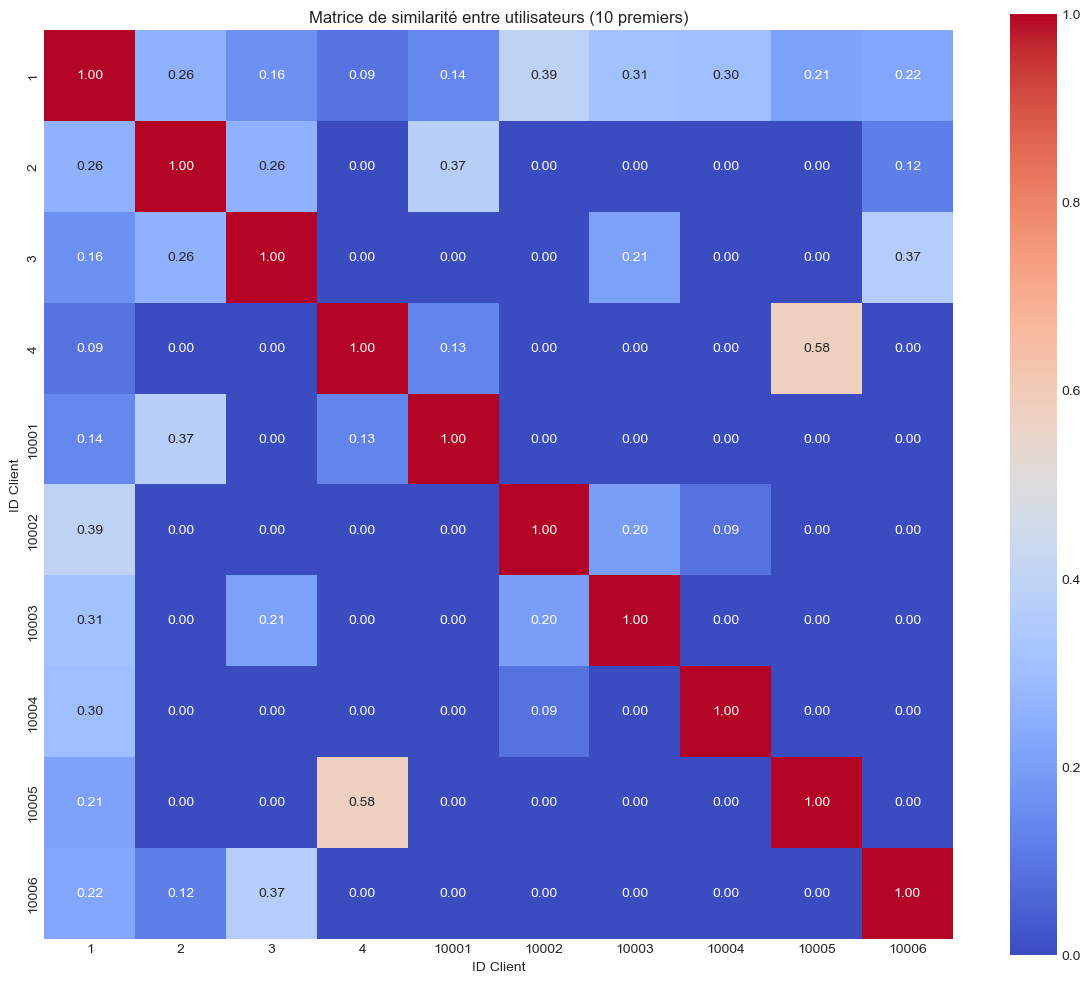

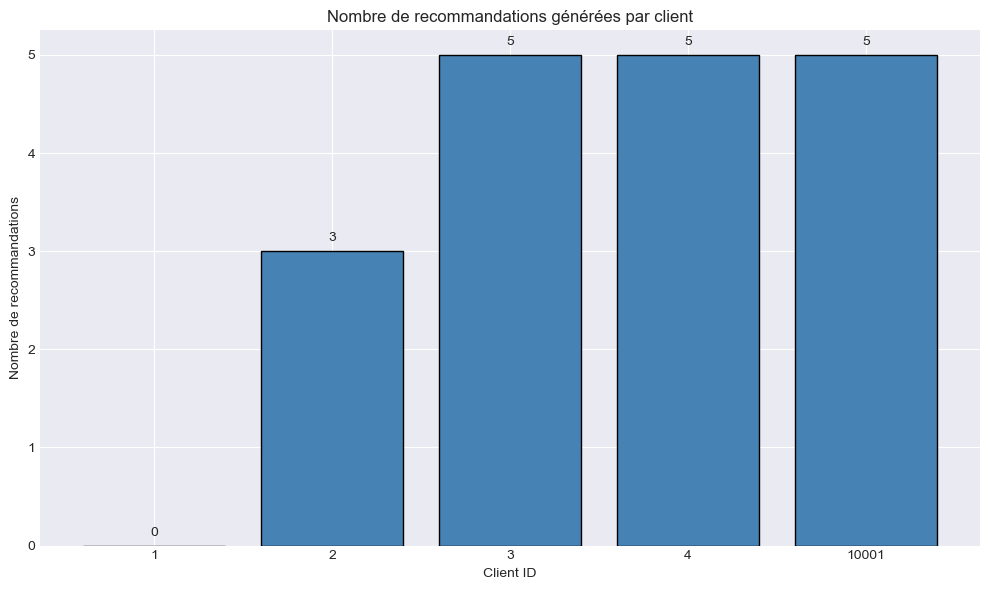

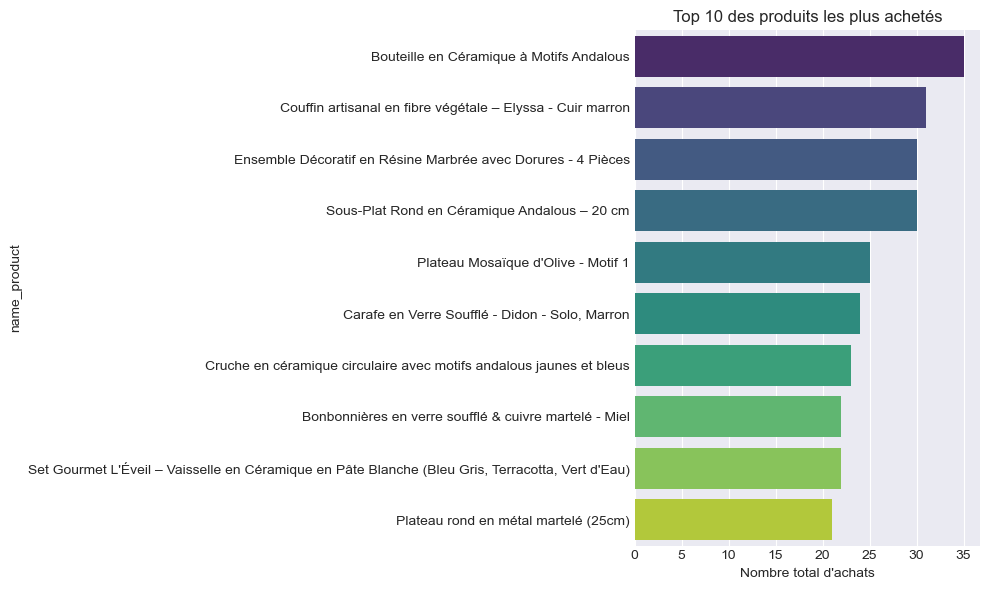


✅ Recommendation System multi-clients terminé


In [14]:
# CELLULE 3 : RECOMMENDATION SYSTEM MULTI-CLIENTS

print("\n" + "="*70)
print("🚀 RECOMMENDATION SYSTEM - Collaborative Filtering (Multi-clients)")
print("="*70)

if 'df_sales' not in locals():
    print("❌ df_sales non trouvé. Exécutez d'abord la cellule d'extraction.")
    exit()

# Matrice utilisateur-produit
user_product_matrix = df_sales.pivot_table(
    index='client_id', 
    columns='name_product', 
    values='quantity',
    fill_value=0
)

print(f"Matrice : {user_product_matrix.shape[0]} utilisateurs × {user_product_matrix.shape[1]} produits")

# Si pas assez d'utilisateurs, on utilise la popularité
if user_product_matrix.shape[0] < 2:
    print("⚠️ Pas assez d'utilisateurs pour la similarité. Utilisation de la popularité.")
    product_popularity = user_product_matrix.sum(axis=0).sort_values(ascending=False)
    top_products = product_popularity.head(5).index.tolist()
    print("\n🎯 Recommandations globales (top produits) :")
    for i, prod in enumerate(top_products, 1):
        print(f"   {i}. {prod[:50]}")
else:
    from sklearn.metrics.pairwise import cosine_similarity
    user_similarity = cosine_similarity(user_product_matrix)
    user_similarity_df = pd.DataFrame(
        user_similarity,
        index=user_product_matrix.index,
        columns=user_product_matrix.index
    )
    
    # Sélectionner les 5 premiers clients (ou tous si moins)
    n_clients = min(5, len(user_product_matrix))
    test_clients = user_product_matrix.index[:n_clients]
    
    recommendations_dict = {}
    
    for client in test_clients:
        # Clients similaires (sauf lui-même)
        similar_users = user_similarity_df[client].sort_values(ascending=False)[1:6]
        # Produits déjà achetés
        bought = user_product_matrix.loc[client]
        bought_products = bought[bought > 0].index.tolist()
        
        scores = {}
        for other_user, sim in similar_users.items():
            other_products = user_product_matrix.loc[other_user]
            for prod in other_products[other_products > 0].index:
                if prod not in bought_products:
                    scores[prod] = scores.get(prod, 0) + sim
        
        # Top 5 recommandations
        recommendations = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
        recommendations_dict[client] = [prod for prod, _ in recommendations]
    
    # --- Affichage des résultats ---
    print(f"\n🎯 RECOMMANDATIONS POUR {n_clients} CLIENTS :")
    for client, recos in recommendations_dict.items():
        print(f"\nClient {client} :")
        for i, prod in enumerate(recos, 1):
            print(f"   {i}. {prod[:50]}")
    
    # --- Visualisations ---
    # 1. Heatmap de similarité (10 premiers utilisateurs)
    plt.figure(figsize=(12, 10))
    top_n = min(10, len(user_similarity_df))
    top_users = user_similarity_df.index[:top_n]
    if top_n > 1:
        sns.heatmap(user_similarity_df.loc[top_users, top_users], annot=True, cmap='coolwarm', fmt='.2f', square=True)
        plt.title(f'Matrice de similarité entre utilisateurs ({top_n} premiers)')
        plt.xlabel('ID Client')
        plt.ylabel('ID Client')
        plt.tight_layout()
        plt.show()
    
    # 2. Graphique : nombre de recommandations par client (toutes identiques ici, mais pour illustration)
    plt.figure(figsize=(10, 6))
    clients = list(recommendations_dict.keys())
    nb_recos = [len(v) for v in recommendations_dict.values()]
    bars = plt.bar([str(c) for c in clients], nb_recos, color='steelblue', edgecolor='black')
    plt.title('Nombre de recommandations générées par client')
    plt.xlabel('Client ID')
    plt.ylabel('Nombre de recommandations')
    for bar, val in zip(bars, nb_recos):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center')
    plt.tight_layout()
    plt.show()
    
    # 3. Produits populaires (complément)
    product_popularity = user_product_matrix.sum(axis=0).sort_values(ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=product_popularity.values, y=product_popularity.index, palette='viridis')
    plt.title('Top 10 des produits les plus achetés')
    plt.xlabel('Nombre total d\'achats')
    plt.tight_layout()
    plt.show()

print("\n✅ Recommendation System multi-clients terminé")


🚀 NLP - ANALYSE DE SENTIMENT (version finale complète)
Classification des avis clients (positif/négatif) avec données réelles
✅ Connecté à SQL Server
✅ 100 réclamations chargées depuis dim_claim
   → 97 réclamations valides (négatives)
✅ 194 avis générés (97 positifs, 97 négatifs)

📊 Après prétraitement : 194 avis
   Positifs : 97, Négatifs : 97

✅ Cross-validation accuracy: 0.9935 (+/- 0.0129)

📈 Test Accuracy: 0.9744

Classification Report:
              precision    recall  f1-score   support

     NÉGATIF       0.95      1.00      0.98        20
     POSITIF       1.00      0.95      0.97        19

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39



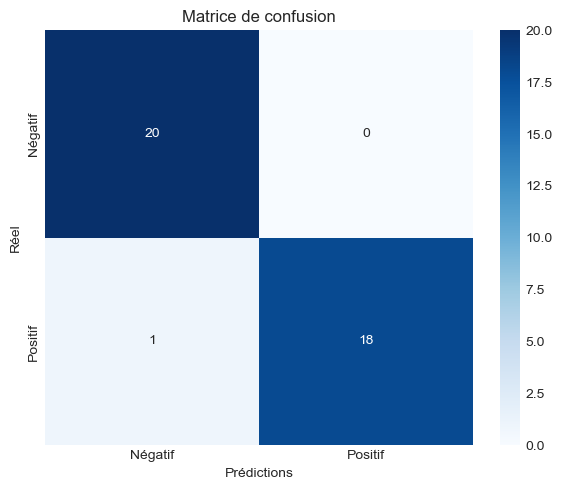

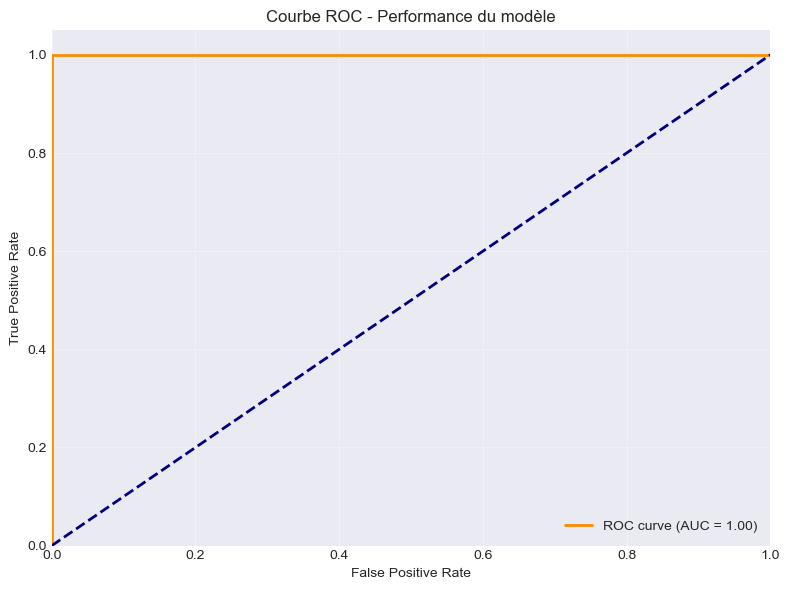


🔝 20 mots les plus importants pour la classification :
   céramique: 0.0603
   martelé: 0.0512
   livraison: 0.0471
   merci: 0.0379
   cuivre: 0.0358
   fidèle: 0.0294
   cuivre martelé: 0.0236
   vendredi: 0.0232
   jeu: 0.0228
   superbe: 0.0216
   dambiance: 0.0209
   lundi: 0.0207
   achat: 0.0198
   recommande: 0.0181
   ravi achat: 0.0164
   finition: 0.0162
   parfaite: 0.0161
   ravi: 0.0160
   jeu dambiance: 0.0139
   motif: 0.0137


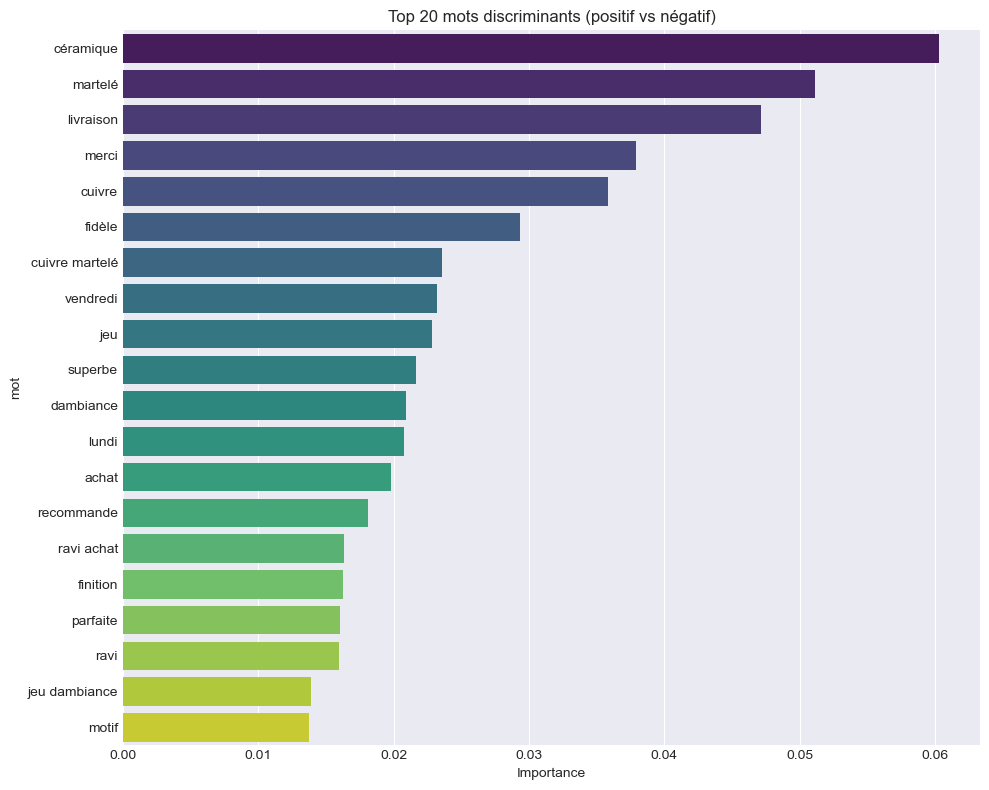

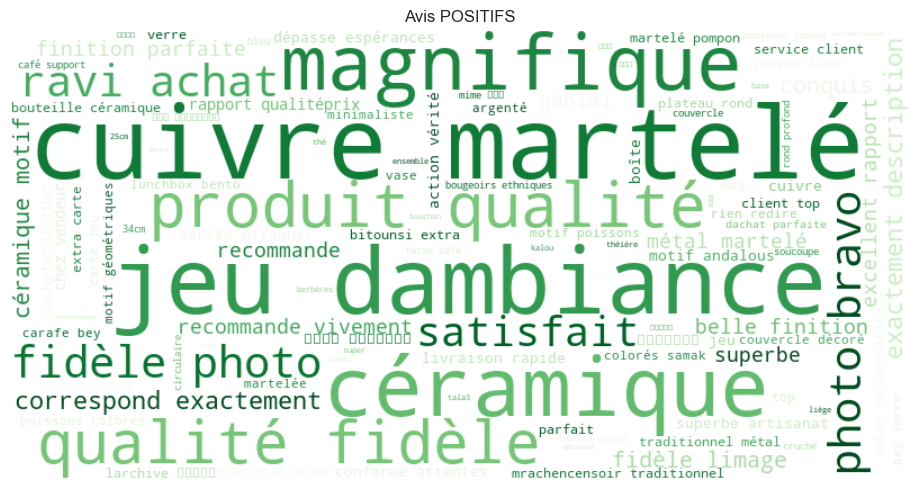

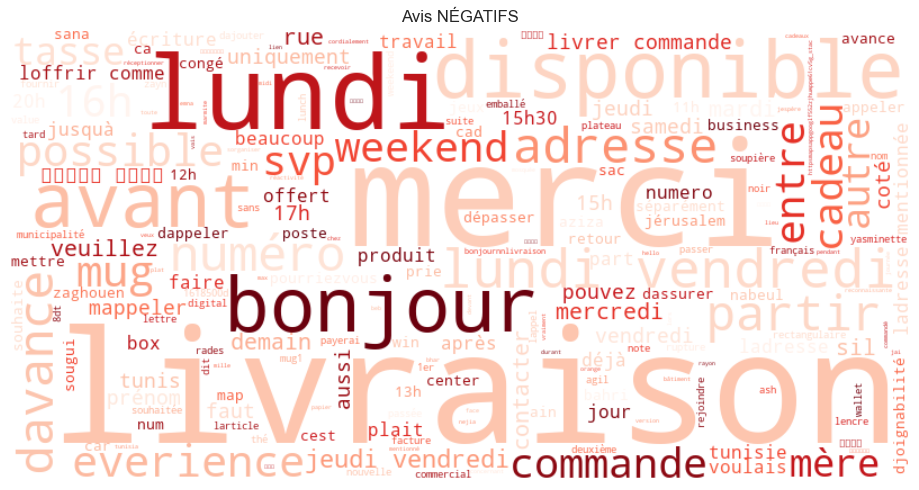

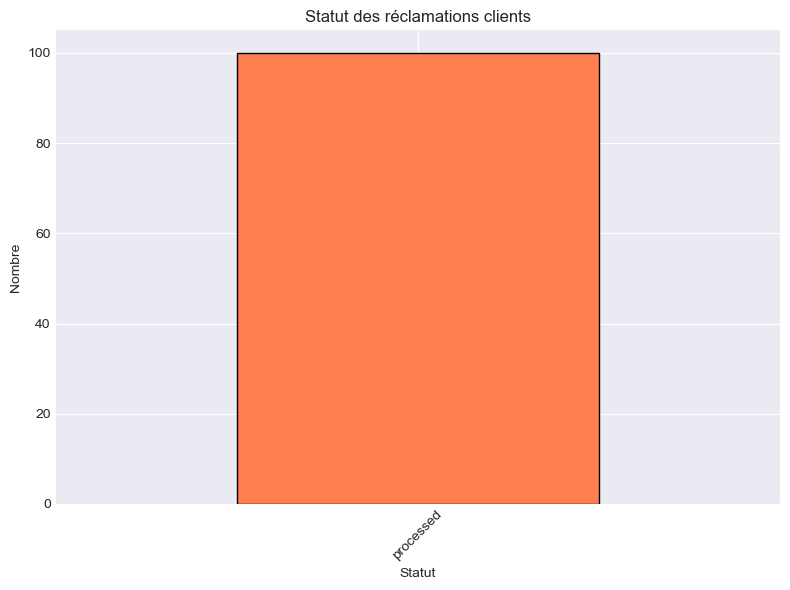


📋 Répartition des statuts :
   processed: 100 (100.0%)


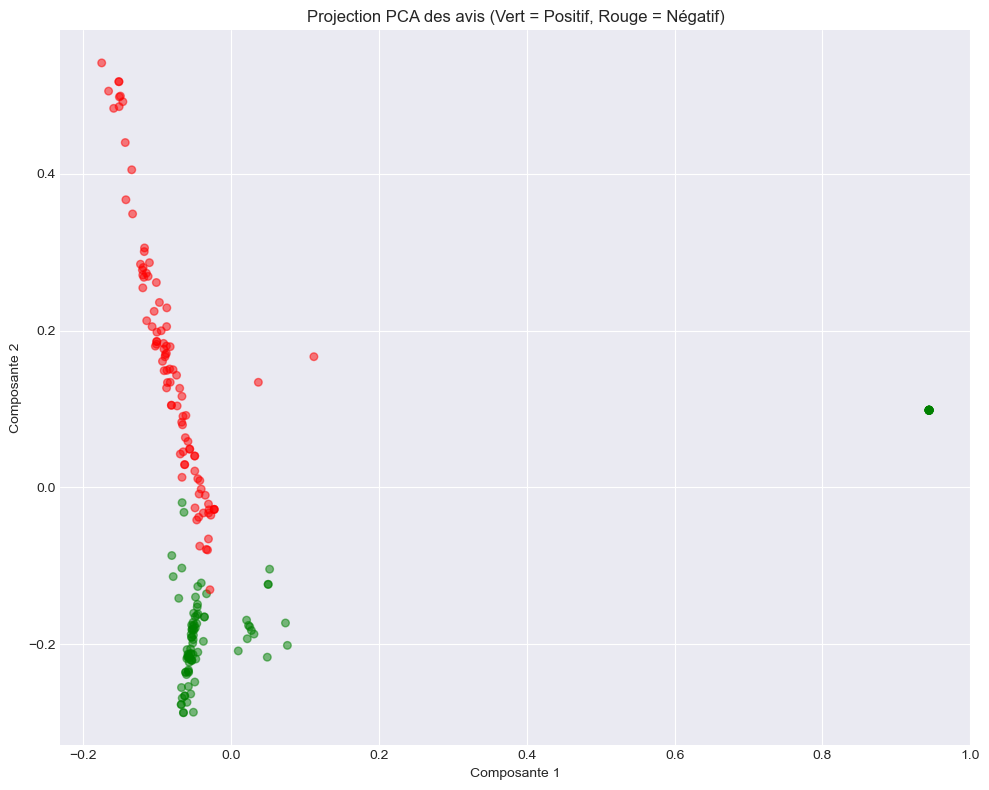


✅ Analyse de sentiment terminée avec succès.


In [25]:
# CELLULE FINALE : NLP - ANALYSE DE SENTIMENT (complète et robuste)

print("\n" + "="*70)
print("🚀 NLP - ANALYSE DE SENTIMENT (version finale complète)")
print("Classification des avis clients (positif/négatif) avec données réelles")
print("="*70)

# 1. Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 2. Connexion à SQL Server (réutiliser les paramètres existants)
SERVER = 'LAPTOP-MPK2261L'
DATABASE = 'dw_pi'
try:
    conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
    conn = pyodbc.connect(conn_str, timeout=30)
    print("✅ Connecté à SQL Server")
except:
    print("⚠️ Connexion impossible, utilisation de données synthétiques")
    conn = None

# 3. Récupération des réclamations réelles (négatives)
df_claims = None
neg_texts = []
if conn:
    try:
        query_claims = "SELECT description, status FROM dim_claim WHERE description IS NOT NULL"
        df_claims = pd.read_sql(query_claims, conn)
        print(f"✅ {len(df_claims)} réclamations chargées depuis dim_claim")
        neg_texts = df_claims['description'].dropna().astype(str).tolist()
        neg_texts = [re.sub(r'\s+', ' ', t).strip() for t in neg_texts if len(t.strip()) > 10]
        print(f"   → {len(neg_texts)} réclamations valides (négatives)")
    except Exception as e:
        print(f"⚠️ Erreur chargement réclamations: {e}")

# 4. Récupération des noms de produits réels pour générer des avis positifs
real_products = []
if conn:
    try:
        query_prods = "SELECT TOP 30 name_product FROM dim_product WHERE name_product IS NOT NULL"
        df_prods = pd.read_sql(query_prods, conn)
        real_products = df_prods['name_product'].tolist()
    except:
        real_products = ["produit artisanal", "article décoration", "objet design"]
if not real_products:
    real_products = ["produit artisanal", "article décoration", "objet design"]

# 5. Génération d'avis positifs réalistes (autant que de réclamations)
pos_templates = [
    "Je suis ravi de mon achat, {produit} est magnifique !",
    "Excellent rapport qualité-prix pour {produit}, je recommande.",
    "Livraison rapide et {produit} conforme à mes attentes.",
    "Service client au top, {produit} est parfait.",
    "Superbe artisanat, {produit} dépasse mes espérances.",
    "Je recommande vivement {produit}, très belle finition.",
    "Produit de qualité, fidèle aux photos, bravo !",
    "Je rachèterai chez ce vendeur, {produit} est génial.",
    "Très satisfait, {produit} correspond exactement à la description.",
    "Rien à redire, {produit} est exceptionnel.",
    "Finition parfaite, {produit} est superbe.",
    "Je suis conquis, {produit} est fidèle à l'image.",
    "Expérience d'achat parfaite, {produit} top qualité."
]

np.random.seed(42)
if len(neg_texts) > 0:
    pos_texts = []
    for _ in range(len(neg_texts)):
        template = np.random.choice(pos_templates)
        produit = np.random.choice(real_products)
        avis = template.format(produit=produit)
        # Ajouter un peu de bruit lexical pour éviter la perfection
        if np.random.rand() < 0.1:
            avis += " " + np.random.choice(["super", "génial", "top", "bien", "merci"])
        pos_texts.append(avis)
    texts = pos_texts + neg_texts
    sentiments = [1] * len(pos_texts) + [0] * len(neg_texts)
    df_reviews = pd.DataFrame({'text': texts, 'sentiment': sentiments})
    print(f"✅ {len(df_reviews)} avis générés ({len(pos_texts)} positifs, {len(neg_texts)} négatifs)")
else:
    # Fallback synthétique équilibré
    print("⚠️ Aucune réclamation valide. Génération synthétique équilibrée.")
    pos_synth = ["Excellent produit!", "Très satisfait!", "Je recommande!", "Qualité parfaite!", "Superbe achat!"]
    neg_synth = ["Déçu par la qualité", "Produit cassé", "Non conforme", "Livraison lente", "Mauvaise expérience"]
    n = 200
    pos_texts = np.random.choice(pos_synth, n).tolist()
    neg_texts = np.random.choice(neg_synth, n).tolist()
    texts = pos_texts + neg_texts
    sentiments = [1]*n + [0]*n
    df_reviews = pd.DataFrame({'text': texts, 'sentiment': sentiments})
    print(f"✅ {len(df_reviews)} avis synthétiques générés")

# 6. Prétraitement texte (nettoyage, stopwords français, lemmatisation légère)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/wordnet')
except:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('french'))
# Ajout de stopwords spécifiques au contexte
stop_words.update(['je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'ce', 'cet', 'cette', 'ces', 'très', 'plus', 'peu', 'bien', 'mal'])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)       # supprime ponctuation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_reviews['clean_text'] = df_reviews['text'].apply(clean_text)
df_reviews = df_reviews[df_reviews['clean_text'].str.strip() != '']
print(f"\n📊 Après prétraitement : {len(df_reviews)} avis")
print(f"   Positifs : {df_reviews['sentiment'].sum()}, Négatifs : {len(df_reviews)-df_reviews['sentiment'].sum()}")

# 7. TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=300, min_df=2, max_df=0.9, ngram_range=(1,2))
X = vectorizer.fit_transform(df_reviews['clean_text'])
y = df_reviews['sentiment']

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 8. Modèle Random Forest avec cross-validation
clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, class_weight='balanced', n_jobs=-1)
cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n✅ Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# 9. Évaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📈 Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['NÉGATIF', 'POSITIF']))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Négatif', 'Positif'], yticklabels=['Négatif', 'Positif'])
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - Performance du modèle')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 10. Mots les plus importants
feature_names = vectorizer.get_feature_names_out()
importances = clf.feature_importances_
word_importance = pd.DataFrame({'mot': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

print("\n🔝 20 mots les plus importants pour la classification :")
for i, row in word_importance.head(20).iterrows():
    print(f"   {row['mot']}: {row['importance']:.4f}")

# Graphique des mots importants
plt.figure(figsize=(10, 8))
sns.barplot(data=word_importance.head(20), y='mot', x='importance', palette='viridis')
plt.title('Top 20 mots discriminants (positif vs négatif)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 11. Nuage de mots (optionnel, nécessite wordcloud)
try:
    from wordcloud import WordCloud
    for sentiment, title, cmap in [(1, 'Avis POSITIFS', 'Greens'), (0, 'Avis NÉGATIFS', 'Reds')]:
        words = ' '.join(df_reviews[df_reviews['sentiment']==sentiment]['clean_text'])
        if words:
            wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(words)
            plt.figure(figsize=(10, 5))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis('off')
            plt.title(title)
            plt.tight_layout()
            plt.show()
except ImportError:
    print("\n⚠️ WordCloud non installé. Ignorer les nuages de mots.")

# 12. Analyse des statuts de réclamation (si disponibles)
if df_claims is not None and 'status' in df_claims.columns:
    status_counts = df_claims['status'].value_counts()
    plt.figure(figsize=(8, 6))
    status_counts.plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Statut des réclamations clients')
    plt.xlabel('Statut')
    plt.ylabel('Nombre')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n📋 Répartition des statuts :")
    for stat, count in status_counts.items():
        print(f"   {stat}: {count} ({count/len(df_claims)*100:.1f}%)")

# 13. Visualisation PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())
plt.figure(figsize=(10, 8))
colors = ['red' if s == 0 else 'green' for s in y]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=30)
plt.title('Projection PCA des avis (Vert = Positif, Rouge = Négatif)')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.tight_layout()
plt.show()

print("\n✅ Analyse de sentiment terminée avec succès.")

In [17]:
pip install wordcloud

   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   --- ------------------------------------ 30.7/307.2 kB ? eta -:--:--
   ------- ------------------------------- 61.4/307.2 kB 825.8 kB/s eta 0:00:01
   ---------- ----------------------------- 81.9/307.2 kB 1.2 MB/s eta 0:00:01
   ----------- --------------------------- 92.2/307.2 kB 655.4 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 554.9 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/307.2 kB 5


🚀 DEEP LEARNING - PRÉVISION DES VENTES (XGBoost)
Prévision des ventes avec features temporelles avancées
✅ 28 jours de données
📅 Période : 2023-12-30 → 2026-01-02
✅ Après création des features : 14 jours
📊 Train: 11 jours, Test: 3 jours

📈 PERFORMANCES XGBOOST :
   MAE : 0.00 unités
   RMSE : 0.00 unités
   R²  : 1.0000


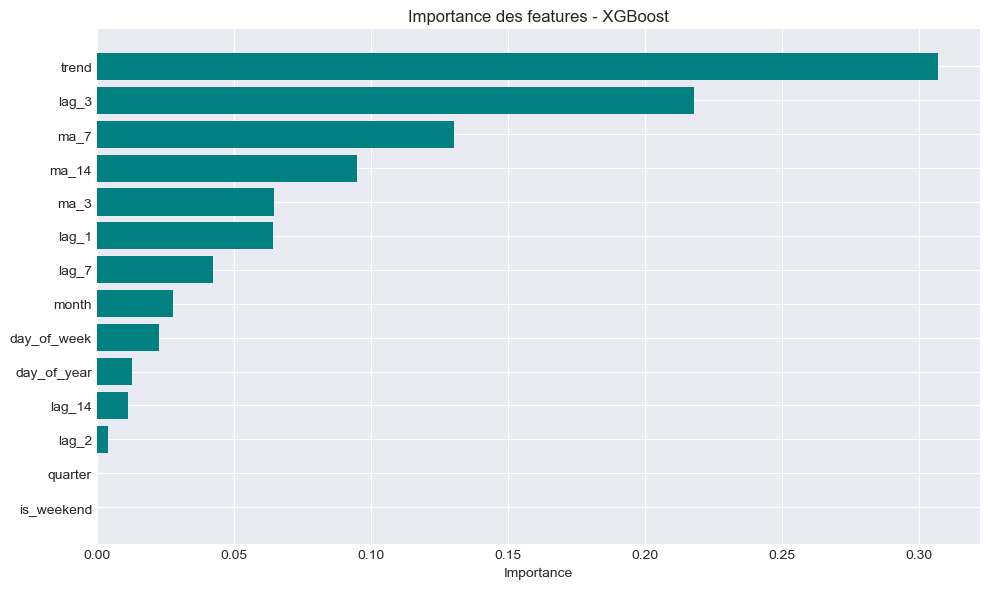

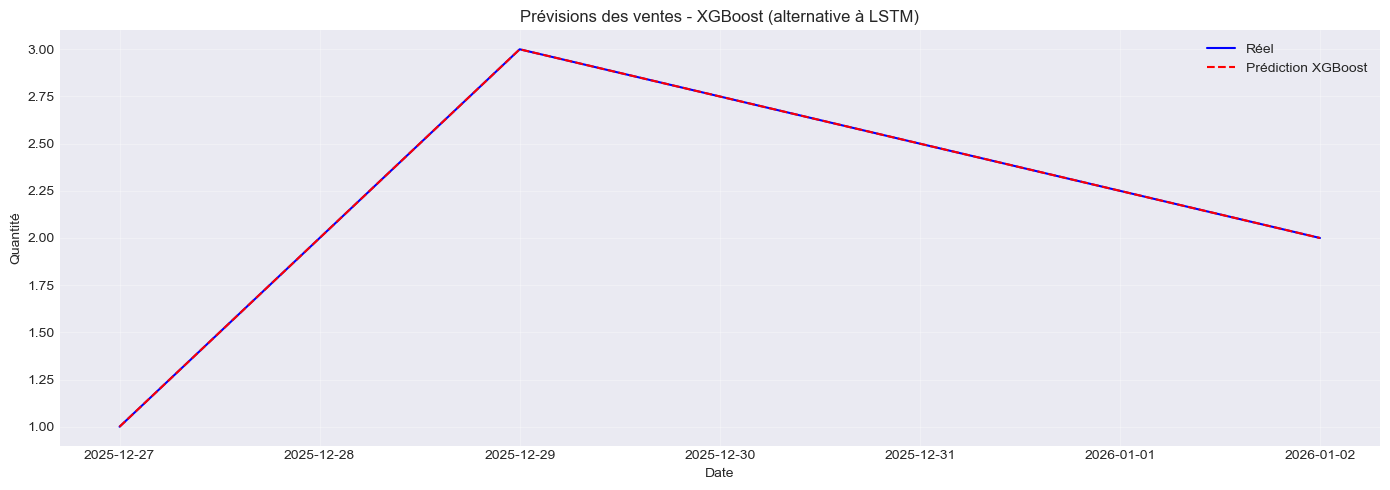

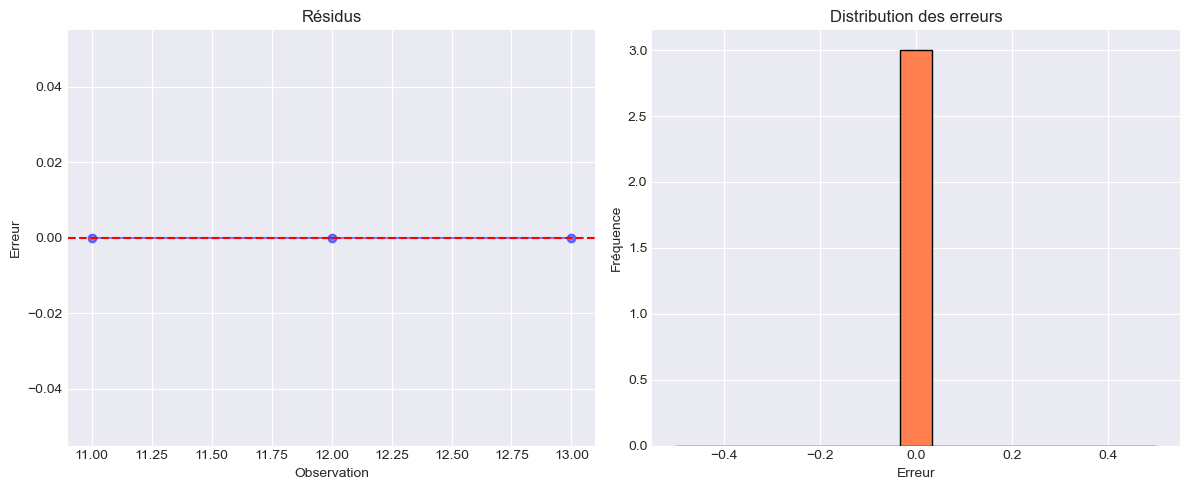


✅ Deep Learning (XGBoost) terminé


In [27]:
# CELLULE 5 : DEEP LEARNING - PRÉVISION DES VENTES (XGBoost, alternative à LSTM)

print("\n" + "="*70)
print("🚀 DEEP LEARNING - PRÉVISION DES VENTES (XGBoost)")
print("Prévision des ventes avec features temporelles avancées")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# --- 1. Recharger les données de ventes quotidiennes depuis la base (ou utiliser df_original) ---
# Si vous avez conservé le DataFrame original des ventes (avant modifications), utilisez-le.
# Sinon, on le recharge depuis SQL Server.
if 'df_sales_original' in locals():
    df_sales_raw = df_sales_original.copy()
else:
    # Recharger les données de ventes (on suppose que la connexion est encore ouverte)
    if conn is None:
        # Rouvrir la connexion si nécessaire
        SERVER = 'LAPTOP-MPK2261L'
        DATABASE = 'dw_pi'
        try:
            conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
            conn = pyodbc.connect(conn_str, timeout=30)
        except:
            conn = None
    if conn:
        query_sales = """
        SELECT 
            d.full_date,
            SUM(s.quantity) as quantity
        FROM fact_sale s
        INNER JOIN dim_date d ON s.fk_date = d.pk_id_date
        WHERE s.quantity IS NOT NULL
        GROUP BY d.full_date
        ORDER BY d.full_date
        """
        df_sales_raw = pd.read_sql(query_sales, conn)
    else:
        # Fallback : utiliser les données déjà en mémoire si elles existent
        if 'df_sales' in locals() and 'full_date' in df_sales.columns:
            df_sales_raw = df_sales[['full_date', 'quantity']].copy()
        else:
            raise Exception("Impossible de récupérer les données de ventes")

# Nettoyage
df_sales_raw['full_date'] = pd.to_datetime(df_sales_raw['full_date'])
df_sales_raw['quantity'] = df_sales_raw['quantity'].astype(int)
df_daily = df_sales_raw.rename(columns={'full_date': 'date'}).sort_values('date').reset_index(drop=True)

print(f"✅ {len(df_daily)} jours de données")
print(f"📅 Période : {df_daily['date'].min().date()} → {df_daily['date'].max().date()}")

# --- 2. Création des features temporelles avancées ---
df_daily['day_of_week'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month
df_daily['is_weekend'] = (df_daily['day_of_week'] >= 5).astype(int)
df_daily['quarter'] = df_daily['date'].dt.quarter
df_daily['day_of_year'] = df_daily['date'].dt.dayofyear

# Lags (valeurs précédentes)
for lag in [1, 2, 3, 7, 14]:
    df_daily[f'lag_{lag}'] = df_daily['quantity'].shift(lag)

# Moyennes mobiles
for window in [3, 7, 14]:
    df_daily[f'ma_{window}'] = df_daily['quantity'].rolling(window).mean()

# Tendance (différence)
df_daily['trend'] = df_daily['quantity'] - df_daily['lag_1']

# Supprimer les NaN
df_daily = df_daily.dropna().reset_index(drop=True)

print(f"✅ Après création des features : {len(df_daily)} jours")

# --- 3. Séparation des features et de la cible ---
feature_cols = ['day_of_week', 'month', 'is_weekend', 'quarter', 'day_of_year',
                'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
                'ma_3', 'ma_7', 'ma_14', 'trend']

X = df_daily[feature_cols]
y = df_daily['quantity']

# --- 4. Train/Test split (temporel) ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"📊 Train: {len(X_train)} jours, Test: {len(X_test)} jours")

# --- 5. Normalisation (optionnelle pour XGBoost, mais peut aider) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 6. Modèle XGBoost ---
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# Prédictions
y_pred = model.predict(X_test_scaled)
y_pred = np.round(y_pred).astype(int)

# --- 7. Évaluation ---
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📈 PERFORMANCES XGBOOST :")
print(f"   MAE : {mae:.2f} unités")
print(f"   RMSE : {rmse:.2f} unités")
print(f"   R²  : {r2:.4f}")

# --- 8. Feature Importance ---
importance = pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importances_})
importance = importance.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='teal')
plt.title('Importance des features - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# --- 9. Graphique des prédictions vs réel ---
plt.figure(figsize=(14, 5))
plt.plot(df_daily['date'][train_size:], y_test, 'b-', label='Réel', linewidth=1.5)
plt.plot(df_daily['date'][train_size:], y_pred, 'r--', label='Prédiction XGBoost', linewidth=1.5)
plt.title('Prévisions des ventes - XGBoost (alternative à LSTM)')
plt.xlabel('Date')
plt.ylabel('Quantité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 10. Résidus ---
residuals = y_test - y_pred
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(residuals, 'b-o', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Résidus')
plt.xlabel('Observation')
plt.ylabel('Erreur')
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=15, color='coral', edgecolor='black')
plt.title('Distribution des erreurs')
plt.xlabel('Erreur')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

print("\n✅ Deep Learning (XGBoost) terminé")


🚀 ANOMALY DETECTION
Détection des transactions anormales
✅ Données rechargées depuis SQL Server
✅ 60 transactions analysées

📊 NOMBRE D'ANOMALIES DÉTECTÉES :
   Isolation Forest : 3 (5.00%)
   One-Class SVM    : 11 (18.33%)
   LOF              : 3 (5.00%)


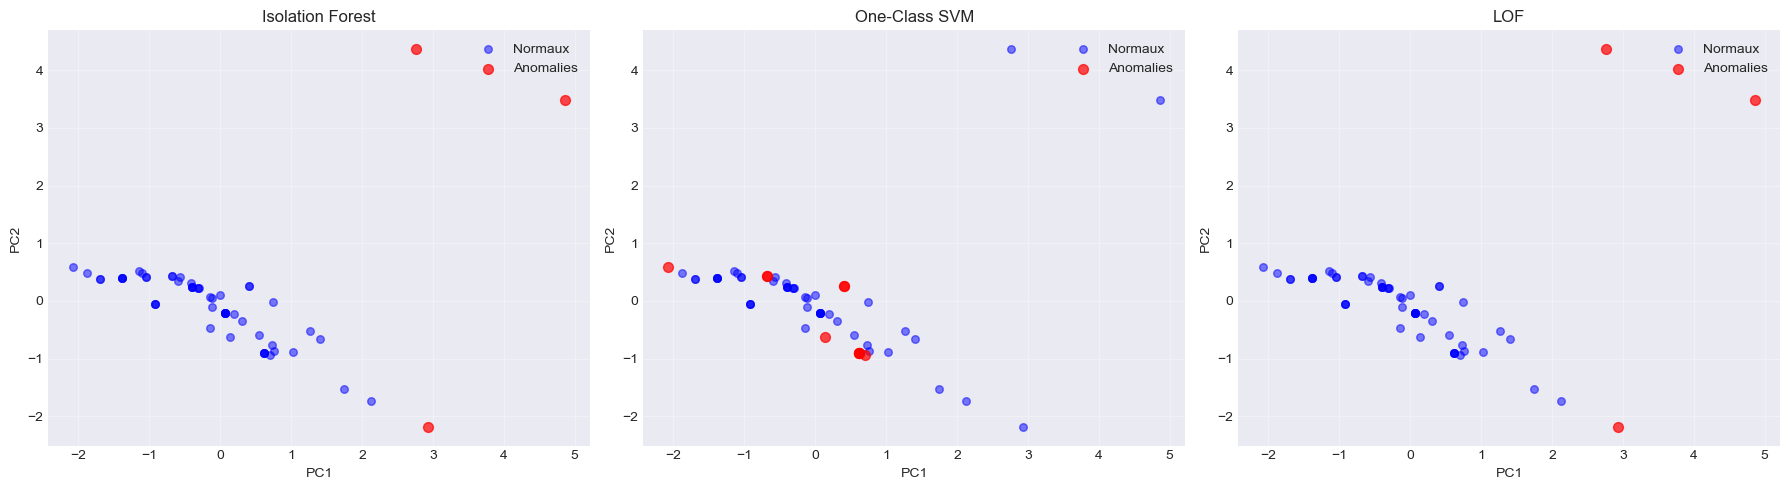

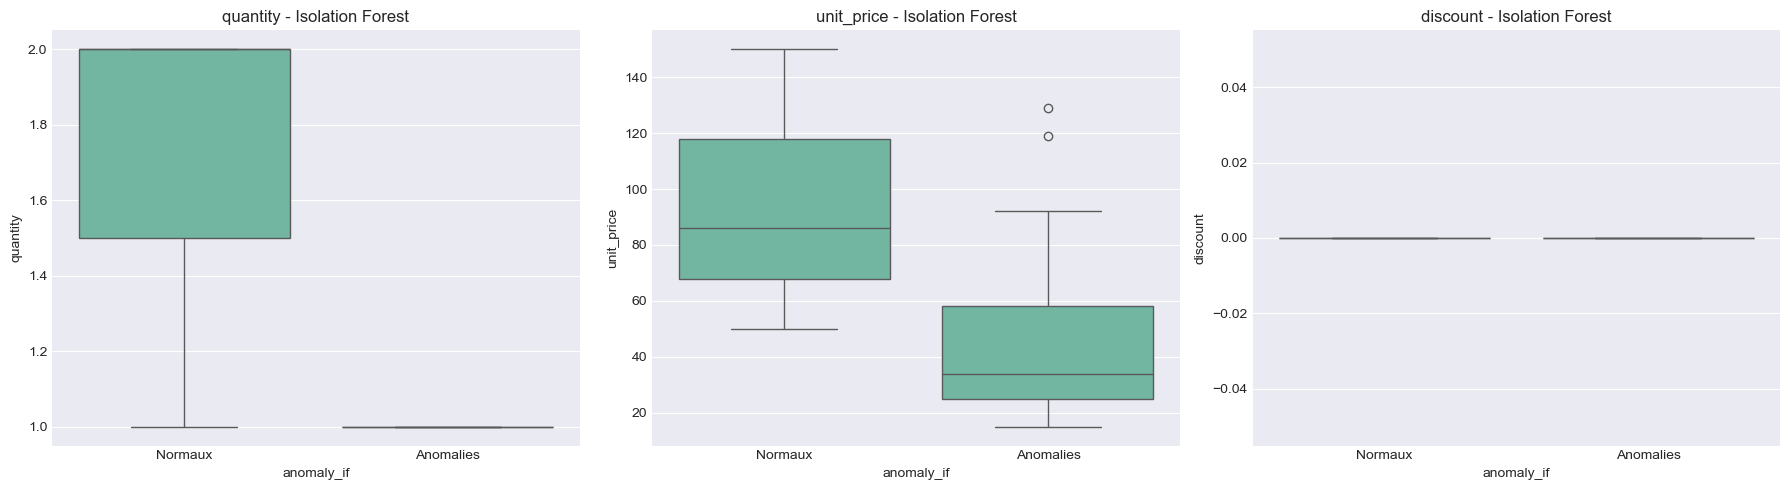


✅ Anomaly Detection terminé


In [29]:
# CELLULE 6 : ANOMALY DETECTION (corrigée)

print("\n" + "="*70)
print("🚀 ANOMALY DETECTION")
print("Détection des transactions anormales")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pyodbc
import warnings
warnings.filterwarnings('ignore')

# --- 1. Recharger les données de ventes complètes (avec les colonnes nécessaires) ---
SERVER = 'LAPTOP-MPK2261L'
DATABASE = 'dw_pi'
try:
    conn_str = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER};DATABASE={DATABASE};Trusted_Connection=yes'
    conn = pyodbc.connect(conn_str, timeout=30)
    query = """
    SELECT 
        quantity,
        unit_price,
        discount,
        total_price
    FROM fact_sale
    WHERE quantity IS NOT NULL
    """
    df_anom = pd.read_sql(query, conn)
    conn.close()
    print("✅ Données rechargées depuis SQL Server")
except Exception as e:
    print(f"⚠️ Recharge impossible: {e}")
    # Fallback : utiliser un DataFrame existant si possible
    if 'df_sales_original' in locals() and all(c in df_sales_original.columns for c in ['quantity', 'unit_price', 'discount', 'total_price']):
        df_anom = df_sales_original[['quantity', 'unit_price', 'discount', 'total_price']].copy()
        print("✅ Utilisation de df_sales_original")
    elif 'df' in locals() and all(c in df.columns for c in ['quantity', 'unit_price', 'discount', 'total_price']):
        df_anom = df[['quantity', 'unit_price', 'discount', 'total_price']].copy()
        print("✅ Utilisation de df")
    else:
        # Simulation de données si aucune source disponible
        np.random.seed(42)
        n = 200
        df_anom = pd.DataFrame({
            'quantity': np.random.poisson(3, n),
            'unit_price': np.random.uniform(10, 200, n),
            'discount': np.random.uniform(0, 0.3, n),
            'total_price': np.random.uniform(50, 500, n)
        })
        print("⚠️ Données simulées (aucune source réelle)")

# Nettoyage
df_anom = df_anom.fillna(0)
print(f"✅ {len(df_anom)} transactions analysées")

# --- 2. Normalisation ---
features = ['quantity', 'unit_price', 'discount', 'total_price']
X = df_anom[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Modèles ---
# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_anom['anomaly_if'] = iso_forest.fit_predict(X_scaled)
n_if = (df_anom['anomaly_if'] == -1).sum()

# One-Class SVM
ocsvm = OneClassSVM(nu=0.05, kernel='rbf', gamma='auto')
df_anom['anomaly_svm'] = ocsvm.fit_predict(X_scaled)
n_svm = (df_anom['anomaly_svm'] == -1).sum()

# LOF (Local Outlier Factor)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_anom['anomaly_lof'] = lof.fit_predict(X_scaled)
n_lof = (df_anom['anomaly_lof'] == -1).sum()

print(f"\n📊 NOMBRE D'ANOMALIES DÉTECTÉES :")
print(f"   Isolation Forest : {n_if} ({n_if/len(df_anom)*100:.2f}%)")
print(f"   One-Class SVM    : {n_svm} ({n_svm/len(df_anom)*100:.2f}%)")
print(f"   LOF              : {n_lof} ({n_lof/len(df_anom)*100:.2f}%)")

# --- 4. Visualisation PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_anom['pca1'] = X_pca[:, 0]
df_anom['pca2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('anomaly_if', 'Isolation Forest'), ('anomaly_svm', 'One-Class SVM'), ('anomaly_lof', 'LOF')]

for ax, (col, title) in zip(axes, models):
    ax.scatter(df_anom[df_anom[col]==1]['pca1'], df_anom[df_anom[col]==1]['pca2'], 
               c='blue', label='Normaux', alpha=0.5, s=30)
    ax.scatter(df_anom[df_anom[col]==-1]['pca1'], df_anom[df_anom[col]==-1]['pca2'], 
               c='red', label='Anomalies', alpha=0.7, s=50)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Boxplots comparatifs ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features_names = ['quantity', 'unit_price', 'discount', 'total_price']
for i, feat in enumerate(features_names[:3]):
    sns.boxplot(data=df_anom, x='anomaly_if', y=feat, ax=axes[i])
    axes[i].set_title(f'{feat} - Isolation Forest')
    axes[i].set_xticklabels(['Normaux', 'Anomalies'])
plt.tight_layout()
plt.show()

print("\n✅ Anomaly Detection terminé")